In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain.chat_models import init_chat_model
llm  = init_chat_model(model_provider="groq", model="llama-3.1-8b-instant")


c:\Users\mendh\Langchain-Langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


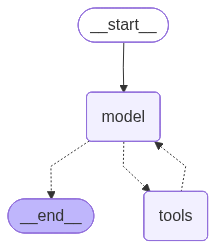

In [5]:
from langchain.agents import create_agent

def Greetings(Name:str):
     """This Function is used to greet people with name as input"""
     return f"Good Morning {Name}, How are you doing today. hope you are fine"

agent = create_agent(
    model = llm,
    tools = [Greetings],
    system_prompt="You are a helpful assistant."
)
agent

In [9]:
agent.invoke({"messages":[{"role":"user","content":"HI, I am Vishal"}]})

{'messages': [HumanMessage(content='HI, I am Vishal', additional_kwargs={}, response_metadata={}, id='a7743a02-a631-4171-8bf8-c53d12ce0a08'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '59b5ggbvt', 'function': {'arguments': '{"Name":"Vishal"}', 'name': 'Greetings'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 232, 'total_tokens': 248, 'completion_time': 0.024224719, 'completion_tokens_details': None, 'prompt_time': 0.015901034, 'prompt_tokens_details': None, 'queue_time': 0.046517396, 'total_time': 0.040125753}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4f10-51bd-7921-840f-54bf0fa35bd5-0', tool_calls=[{'name': 'Greetings', 'args': {'Name': 'Vishal'}, 'id': '59b5ggbvt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 232, 'outp

In [10]:
import os
from langchain.chat_models import init_chat_model

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

model = init_chat_model("groq:qwen/qwen3-32b")

response = model.invoke("How does rivers are formed?")

response

AIMessage(content="<think>\nOkay, so I need to figure out how rivers are formed. Let me start by recalling what I know. I think rivers come from somewhere, maybe from rain or melting snow. But how exactly does that process work? Let me break it down step by step.\n\nFirst, maybe it starts with precipitation. When it rains or snows, the water needs to go somewhere. Some of it might soak into the ground, right? That's called infiltration. But if there's too much rain, or if the ground is already saturated, the water can't soak in anymore. Then it starts to run over the surface, which is called surface runoff. That runoff might collect in low areas, forming streams or rivers.\n\nWait, but where does the water initially come from? Maybe in mountainous regions, snow and ice melt during warmer periods. That meltwater could flow down slopes and contribute to river formation. Also, groundwater seepage plays a role. Groundwater is water stored in the ground, and it can seep out into the ground 

In [11]:
print(response.content)

<think>
Okay, so I need to figure out how rivers are formed. Let me start by recalling what I know. I think rivers come from somewhere, maybe from rain or melting snow. But how exactly does that process work? Let me break it down step by step.

First, maybe it starts with precipitation. When it rains or snows, the water needs to go somewhere. Some of it might soak into the ground, right? That's called infiltration. But if there's too much rain, or if the ground is already saturated, the water can't soak in anymore. Then it starts to run over the surface, which is called surface runoff. That runoff might collect in low areas, forming streams or rivers.

Wait, but where does the water initially come from? Maybe in mountainous regions, snow and ice melt during warmer periods. That meltwater could flow down slopes and contribute to river formation. Also, groundwater seepage plays a role. Groundwater is water stored in the ground, and it can seep out into the ground and feed into rivers.

T

In [12]:
from langchain.tools import tool

@tool
def get_weather(location:str):
    """Get the weather at a location"""
    return f"Its sunny in {location}"

model_with_tools = model.bind_tools([get_weather])

In [13]:
model_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014B82801810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014B82802210>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Get the weather at a location', 'parameters': {'properties': {'location': {'type': 'string'}}, 'required': ['location'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [14]:
response = model_with_tools.invoke("Whats the weather likein Hyderabad?")
print(response)

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Hyderabad. Let me check if I have the right tool for that. The available tool is get_weather, which requires a location parameter. Hyderabad is a location, so I should use that function. I need to make sure the argument is correctly formatted as a JSON object with the "location" key. Let me structure the tool call accordingly.\n', 'tool_calls': [{'id': '5j3jsavqp', 'function': {'arguments': '{"location":"Hyderabad"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 153, 'total_tokens': 256, 'completion_time': 0.159351654, 'completion_tokens_details': {'reasoning_tokens': 78}, 'prompt_time': 0.006247078, 'prompt_tokens_details': None, 'queue_time': 0.156612406, 'total_time': 0.165598732}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls'

### Tool Execution Loops

In [16]:
messages = [{"role":"user","content":"Whats's the weather in Hyderabad?"}]

ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

ai_msg

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Hyderabad. I need to use the get_weather function. The function requires a location parameter. Hyderabad is a city in India, so I should specify that as the location. I\'ll call the function with "Hyderabad, India" to ensure it\'s clear. Let me make sure the JSON is formatted correctly with the location parameter. Yep, that\'s all set.\n', 'tool_calls': [{'id': '26yzwhrm3', 'function': {'arguments': '{"location":"Hyderabad, India"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 153, 'total_tokens': 263, 'completion_time': 0.22097235, 'completion_tokens_details': {'reasoning_tokens': 83}, 'prompt_time': 0.013358641, 'prompt_tokens_details': None, 'queue_time': 0.053652478, 'total_time': 0.234330991}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'fin